# Request Class Prediction and Reduction

One task given by the sponsor was to predict the request class of a ticket, as well see if one can reduce the number of request classes, as there are many. The prediction was accomplished using random forest, but the underlying problem of too many request classes still needs to be resolved (WIP). Refinement of the current model is possible as one can see the performance is heavily dependent on the number of occurances to train on. Furthermore, the forest has not yet been trained on the description key words, which may help improve its accuracy. 

### Forest Model
The random forest is trainedon data from the work task data set. Redundant columns were dropped for ease of access, leaving only the 'DESCRIPTION', 'TASK_TYPE', 'TASK_PRIORITY', 'REQUEST_CLASS', 'SERVICE_CLASS', 'BUILDING', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME' columns. There are currently 400 unique request categories, which the sponsor has inquired about reducing. The model was trained using sklearn's random forest and label encoder. 

In [ ]:
import pandas as pd
df_2 = pd.read_csv(r'C:\Users\EC712\Documents\school\DSCI_435\data_sheets\V_OM_WORK_TASK.csv')

In [3]:
#remove bloat columns
df = df_2[['DESCRIPTION', 'TASK_TYPE', 'TASK_PRIORITY', 'REQUEST_CLASS', 'SERVICE_CLASS', 'BUILDING', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME']]
df = df.dropna()

In [4]:
df['REQUEST_CLASS'].unique()

array(['Custodial Issues', 'Other Electrical Issues', 'Other Carpentry',
       'Toilet/Urinal', 'Tires (Billable)',
       'Pest Control - Ant, Roach, Spider',
       'Grounds Event Support (Billable)',
       'Event Moving/Setup/Take Down (Billable)', 'Too Hot',
       'Key Pad Not Working', 'Other Mechanical Repair',
       'Rekey/Install Key Core (Billable)', 'Drain Clogged', 'No Power',
       'HVAC Systems Issues', 'Floor Strip/Wax',
       'Investigate Poor Lighting', 'Pest Control',
       'Custodial Event Support (Billable)',
       'Interior Lights Not Working', 'Plant Equipment - Operations',
       'Equipment Leaking', 'Cart Repairs (Billable)',
       'Drinking Fountain/Water Bottle Filler', 'Service by Vendor',
       'Air Conditioning Leak', 'Air Conditioning Not Working/Noisy',
       'Temperature Issues', 'Leak From Ceiling',
       'Heavy Disposal-Furniture, Equipment (Billable)',
       'Missing Furniture', 'Assemble/Disassemble Furniture (Billable)',
       'Air Qua

In [5]:
import matplotlib.pyplot as plt

#take value counts of each request class to find frequency of each
class_counts = pd.DataFrame(df['REQUEST_CLASS'].value_counts().rename_axis('Class').reset_index(name='Counts'))

# plt.figure(figsize=(10, 8))
# plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
# plt.title('Distribution of Building Class (FEP_BUILDING_CLASS)')
# plt.show()


In [6]:
class_counts

,Class,Counts
0,Interior Lights Not Working,6476
1,Too Hot,3650
2,Toilet/Urinal,2698
3,Other Plumbing Issues,2285
4,Too Cold,2170
...,...,...
379,Residential Laundry Equipment,1
380,Moving Services,1
381,"Cardreader, No Power (Billable)",1
382,"Key Pad, Program Code (Billable)",1


### Count Distribution
One can see that the bulk of the request labels have less than 250 occurances in the dataset, which will affect the forest models accuracy below. If sets the minimum number of observations to be higher, the models performance will improve favorably, albiet with less model diversity. 

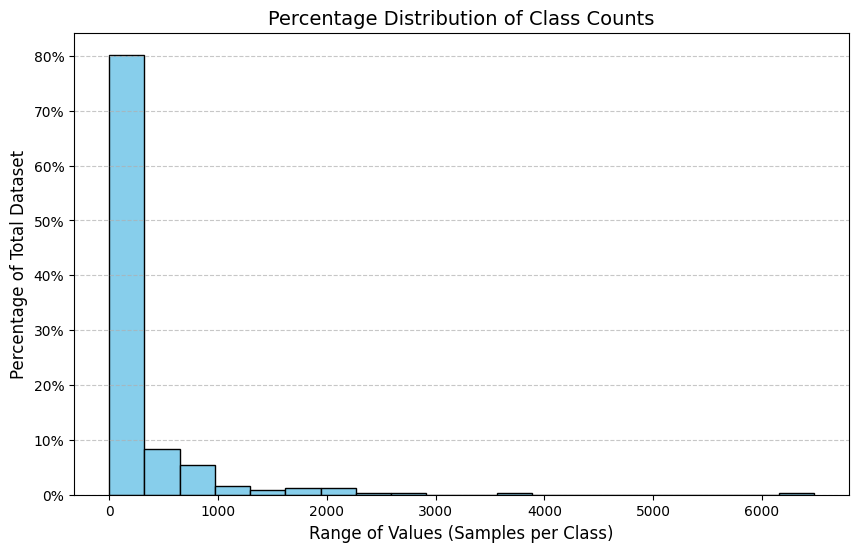

In [7]:
import numpy as np

data = class_counts['Counts']

plt.figure(figsize=(10, 6))

plt.hist(data, bins=20, edgecolor='black', color='skyblue', 
         weights=np.ones(len(data)) / len(data))

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.title('Percentage Distribution of Class Counts', fontsize=14)
plt.xlabel('Range of Values (Samples per Class)', fontsize=12)
plt.ylabel('Percentage of Total Dataset', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings
import matplotlib.pyplot as plt

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

accuracies = []
macro_precisions = []
macro_recalls = []
macro_f1 = []
weighted_precisions = []
weighted_recalls = []
weighted_f1 = []

#change threshold for min number of tickets 
count_lst = [1, 5, 10, 50, 100, 500, 1000, 2000]

for i in count_lst:
    
    #take only requests class with atleast i occurances
    mod_counts =  class_counts[class_counts['Counts'] >= i]
    filter_df = df[df['REQUEST_CLASS'].isin(mod_counts['Class'])]

    #encode columns for random forest
    le = LabelEncoder()
    for col in filter_df.columns:
        filter_df[col] = le.fit_transform(filter_df[col].astype(str))

    X = filter_df[['TASK_TYPE', 'TASK_PRIORITY', 'SERVICE_CLASS', 'BUILDING', 'CUSTOMER_ORGANIZATION', 'CUSTOMER_DIVISION', 'CUSTOMER_DEPARTMENT', 'RESPONSIBLE_ORGANIZATION_NAME']]
    y = filter_df['REQUEST_CLASS']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = RandomForestClassifier()

    #train
    model.fit(X_train, y_train)

    #predict
    predictions = model.predict(X_test)
    
    #compare
    results = classification_report(y_test, predictions, output_dict=True)

    accuracies.append(results['accuracy'])
    macro_precisions.append(results['macro avg']['precision'])
    macro_recalls.append(results['macro avg']['recall'])
    macro_f1.append(results['macro avg']['f1-score'])
    weighted_precisions.append(results['weighted avg']['precision'])
    weighted_recalls.append(results['weighted avg']['recall'])
    weighted_f1.append(results['weighted avg']['f1-score'])

    print(f'Classification report for {i}')
    print(f'Overall accuracy {results['accuracy']}')
    print(f'Macro percision {results['macro avg']['precision']}')
    print(f'Macro recall {results['macro avg']['recall']}')
    print(f'Macro f1 {results['macro avg']['f1-score']}')
    print(f'Weighted percision {results['weighted avg']['precision']}')
    print(f'Weighted recall {results['weighted avg']['recall']}')
    print(f'Weighted f1 {results['weighted avg']['f1-score']}')

    print('========================================')

Classification report for 1
Overall accuracy 0.5810110846369004
Macro percision 0.3582881860419311
Macro recall 0.32299555236427474
Macro f1 0.3221883118020638
Weighted percision 0.5641075565082809
Weighted recall 0.5810110846369004
Weighted f1 0.5651310383223617
Classification report for 5
Overall accuracy 0.5776568170036288
Macro percision 0.3553192078969661
Macro recall 0.32363256053069756
Macro f1 0.32680841692170765
Weighted percision 0.5600975234462726
Weighted recall 0.5776568170036288
Weighted f1 0.5628004004679897
Classification report for 10
Overall accuracy 0.5816358345458325
Macro percision 0.38333731286332773
Macro recall 0.3626956038811618
Macro f1 0.35942097941656476
Weighted percision 0.5650427749352033
Weighted recall 0.5816358345458325
Weighted f1 0.5674883574225256
Classification report for 50
Overall accuracy 0.5906313645621182
Macro percision 0.4605301072841324
Macro recall 0.4378412006421488
Macro f1 0.4409536985911663
Weighted percision 0.5756667591348752
Weighte

### Model Performance
The models performance was heavily dictated on the minimum number of occurances for the request class. The weighted average of the model is the performance relative to each classes number of occurances (more occurances more weight), where as the model's macro performance is not relative to number of occurances, and treats each request label equally. For models with a cut off of less than 100, one can see that there is a sizeable gap between the accuracy + weighted performance and macro performance, indicating that the classes with more occurances are biasing the model. Of course, as one removes these lower count classes from the dataset, the macro and weighted performance gap narrows at the cost of reduced model classification. 

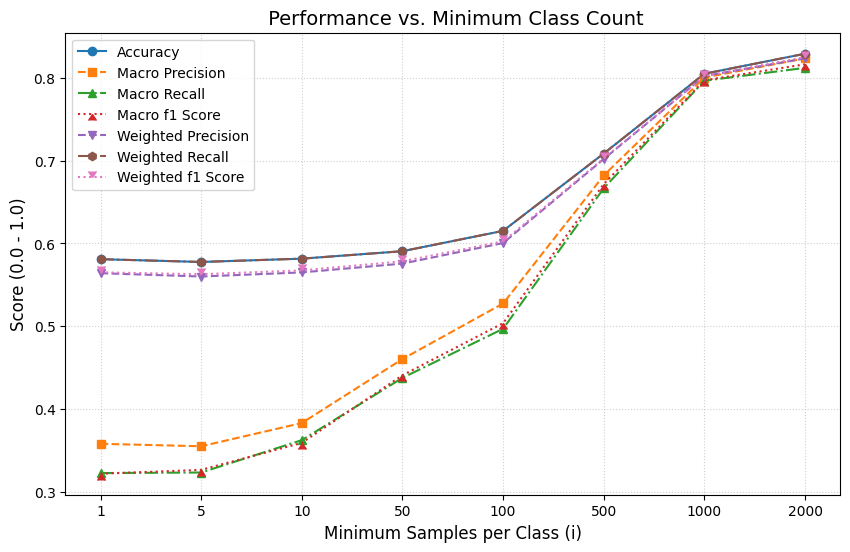

In [12]:
plt.figure(figsize=(10, 6))

x_indices = range(len(count_lst))

plt.plot(x_indices, accuracies, marker='o', label='Accuracy', linestyle='-')
plt.plot(x_indices, macro_precisions, marker='s', label='Macro Precision', linestyle='--')
plt.plot(x_indices, macro_recalls, marker='^', label='Macro Recall', linestyle='-.')
plt.plot(x_indices, macro_f1, marker=6, label='Macro f1 Score', linestyle=':')
plt.plot(x_indices, weighted_precisions, marker='v', label='Weighted Precision', linestyle='--')
plt.plot(x_indices, weighted_recalls, marker='h', label='Weighted Recall', linestyle='-.')
plt.plot(x_indices, weighted_f1, marker=7, label='Weighted f1 Score', linestyle=':')


plt.xticks(ticks=x_indices, labels=count_lst)

plt.title(' Performance vs. Minimum Class Count', fontsize=14)
plt.xlabel('Minimum Samples per Class (i)', fontsize=12)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
df_filter = df.groupby(['REQUEST_CLASS']).size().reset_index(name='COUNT')
df_filter.to_csv('REQ_COUNTS.csv')